In [3]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Used for splitting data into training and testing sets
from sklearn.model_selection import train_test_split

# TensorFlow/Keras libraries used to build the LSTM model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Tokenizer converts text words into numbers
from tensorflow.keras.preprocessing.text import Tokenizer

# pad_sequences makes every text sequence the same length
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Used to display our final insights as Markdown bullets
from IPython.display import display, Markdown


# Set random seeds so results are more reproducible
np.random.seed(42)
tf.random.set_seed(42)

In [4]:


# Load the spam CSV file.
df = pd.read_csv("/content/spam 2.csv", encoding="latin-1")

# Display the first 5 rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:

#number of rows and columns
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

#first few rows
display(df.head())

Dataset shape:
(5572, 5)

Column names:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:


# df.info() shows:
# - column names
# - number of non-null values
# - data types
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
# for both numerical and categorical columns.
display(df.describe(include="all"))

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [8]:
df = df[["v1", "v2"]].copy()

# Rename columns to make them easier to understand
df.columns = ["label", "text"]

# Check the cleaned dataframe
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# Count missing values in each column
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
label    0
text     0
dtype: int64


In [10]:
# These two columns are essential for text classification.
df = df.dropna(subset=["label", "text"])

# Verify that missing values have been removed
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
label    0
text     0
dtype: int64


In [11]:

# Check how many completely duplicated SMS records exist
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 403


In [12]:
# Remove exact duplicate rows so repeated messages
# do not unnecessarily influence the model.
df = df.drop_duplicates().reset_index(drop=True)

# Verify duplicate removal
print("Duplicates remaining:", df.duplicated().sum())

# Check the new dataset size
print("Dataset shape after cleaning:", df.shape)

Duplicates remaining: 0
Dataset shape after cleaning: (5169, 2)


In [13]:
# Count how many messages are ham and spam
print(df["label"].value_counts())

# Display proportions as percentages
print("\nClass percentages:")
print(df["label"].value_counts(normalize=True) * 100)

label
ham     4516
spam     653
Name: count, dtype: int64

Class percentages:
label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


In [14]:

# FEATURE ENGINEERING

# FEATURE 1:
# Number of characters in each SMS message
df["text_length"] = df["text"].str.len()


# FEATURE 2:
# Number of words in each SMS message
df["word_count"] = df["text"].str.split().str.len()


# FEATURE 3:
# Check whether the message contains a currency symbol.
# Spam messages often contain money-related information.
df["contains_currency"] = df["text"].str.contains(
    r"[$£€₹]",
    regex=True
).astype(int)


# FEATURE 4:
# Count the number of numeric digits in each message.
# Spam messages often contain phone numbers, amounts, or codes.
df["digit_count"] = df["text"].apply(
    lambda x: sum(character.isdigit() for character in x)
)


# FEATURE 5:
# Calculate the proportion of uppercase letters.
# Promotional/spam messages may use more capital letters.
def calculate_uppercase_ratio(text):

    # Get only alphabetic characters
    letters = [char for char in text if char.isalpha()]

    # Avoid dividing by zero
    if len(letters) == 0:
        return 0

    # Calculate uppercase proportion
    uppercase_letters = sum(char.isupper() for char in letters)

    return uppercase_letters / len(letters)


df["uppercase_ratio"] = df["text"].apply(calculate_uppercase_ratio)


# Display the engineered features
df.head()

,label,text,text_length,word_count,contains_currency,digit_count,uppercase_ratio
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,0,0,0.036145
1,ham,Ok lar... Joking wif u oni...,29,6,0,0,0.111111
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,0,25,0.103093
3,ham,U dun say so early hor... U c already then say...,49,11,0,0,0.060606
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0,0,0.042553


In [15]:
# View summary statistics for the new features
display(
    df[
        [
            "text_length",
            "word_count",
            "contains_currency",
            "digit_count",
            "uppercase_ratio"
        ]
    ].describe()
)

,text_length,word_count,contains_currency,digit_count,uppercase_ratio
count,5169.000000,5169.000000,5169.000000,5169.000000,5169.000000
mean,78.977945,15.340685,0.045463,2.205069,0.089299
std,58.236293,11.068488,0.208338,6.025241,0.150500
min,2.000000,1.000000,0.000000,0.000000,0.000000
25%,36.000000,7.000000,0.000000,0.000000,0.033333
50%,60.000000,12.000000,0.000000,0.000000,0.050000
75%,117.000000,22.000000,0.000000,1.000000,0.081081
max,910.000000,171.000000,1.000000,47.000000,1.000000


In [16]:
# Calculate first quartile
Q1 = df["text_length"].quantile(0.25)

# Calculate third quartile
Q3 = df["text_length"].quantile(0.75)

# Calculate Interquartile Range
IQR = Q3 - Q1

# Define lower and upper limits
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find unusually long/short messages
text_outliers = df[
    (df["text_length"] < lower_bound) |
    (df["text_length"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper bound:", upper_bound)

print("\nNumber of text-length outliers:")
print(len(text_outliers))

Q1: 36.0
Q3: 117.0
IQR: 81.0
Upper bound: 238.5

Number of text-length outliers:
66


In [17]:
print(
    "Text-length outliers were retained because unusually long "
    "messages may be valid and useful for spam classification."
)

Text-length outliers were retained because unusually long messages may be valid and useful for spam classification.


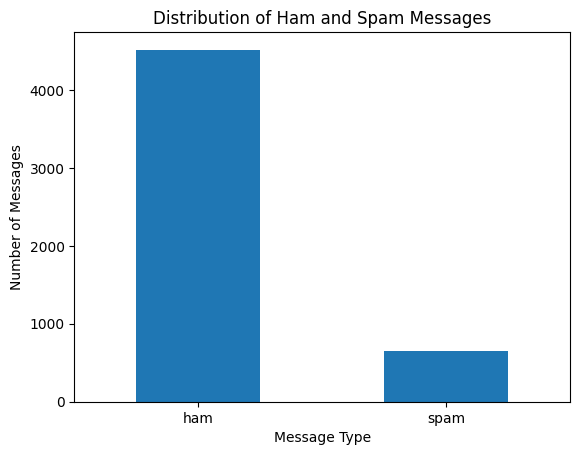

In [18]:

# EDA PLOT 1
# CLASS DISTRIBUTION


# Count each class
class_counts = df["label"].value_counts()

# Create a bar chart
class_counts.plot(kind="bar")

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.xticks(rotation=0)

plt.show()

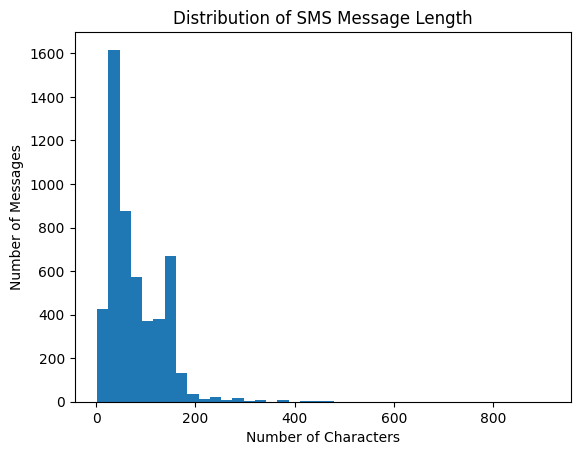

In [19]:

# EDA PLOT 2
# TEXT LENGTH DISTRIBUTION


# Histogram shows how SMS message lengths are distributed
plt.hist(
    df["text_length"],
    bins=40
)

plt.title("Distribution of SMS Message Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Messages")

plt.show()

/tmp/ipykernel_2597/570220009.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


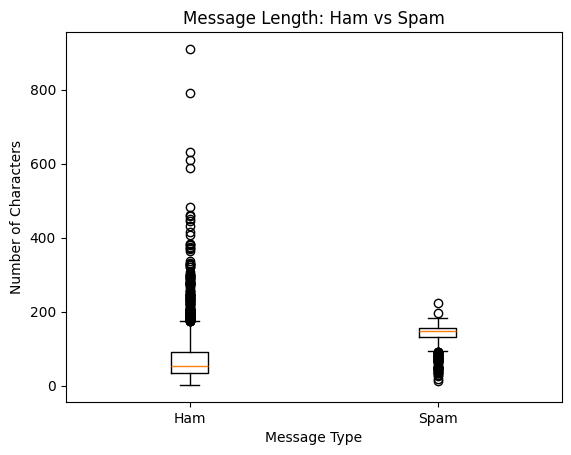

In [20]:

# EDA PLOT 3
# TEXT LENGTH BY MESSAGE TYPE


# Separate message lengths for ham and spam
ham_length = df[df["label"] == "ham"]["text_length"]

spam_length = df[df["label"] == "spam"]["text_length"]


# Create boxplot comparing message length
plt.boxplot(
    [ham_length, spam_length],
    labels=["Ham", "Spam"]
)

plt.title("Message Length: Ham vs Spam")
plt.xlabel("Message Type")
plt.ylabel("Number of Characters")

plt.show()

In [21]:

# CREATE TEXT LENGTH CATEGORIES


# Convert continuous message length into categories
df["length_category"] = pd.cut(
    df["text_length"],
    bins=[0, 50, 100, 150, 200, np.inf],
    labels=[
        "0-50",
        "51-100",
        "101-150",
        "151-200",
        "200+"
    ]
)

# Create a cross-tabulation
length_table = pd.crosstab(
    df["label"],
    df["length_category"]
)

display(length_table)

length_category,0-50,51-100,101-150,151-200,200+
label,,,,,
ham,2168,1373,616,260,99
spam,21,52,276,303,1


In [22]:
group_summary = df.groupby("label")[
    [
        "text_length",
        "word_count",
        "digit_count",
        "uppercase_ratio"
    ]
].mean()

display(group_summary)

,text_length,word_count,digit_count,uppercase_ratio
label,,,,
ham,70.459256,14.134632,0.290301,0.078340
spam,137.891271,23.681470,15.447167,0.165089


In [23]:

# ENCODE TARGET VARIABLE




df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

# Check encoding
df[["label", "label_encoded"]].head()

,label,label_encoded
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [24]:
X = df["text"]

# y contains the binary class:

y = df["label_encoded"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5169,)
y shape: (5169,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [26]:
tokenizer = Tokenizer(
    num_words=5000
)

# Learn the vocabulary ONLY from training data.
# This prevents information from the test set leaking into training.
tokenizer.fit_on_texts(X_train)


# Convert training sentences into sequences of integers
X_train_sequences = tokenizer.texts_to_sequences(
    X_train
)


# Convert testing sentences using the same tokenizer
X_test_sequences = tokenizer.texts_to_sequences(
    X_test
)

In [27]:

X_train_pad = pad_sequences(
    X_train_sequences,
    maxlen=50
)

X_test_pad = pad_sequences(
    X_test_sequences,
    maxlen=50
)


# Check resulting shapes
print("Padded training shape:", X_train_pad.shape)
print("Padded testing shape:", X_test_pad.shape)

Padded training shape: (4135, 50)
Padded testing shape: (1034, 50)


In [28]:
model = Sequential([

    # Convert each word/token into a 32-dimensional embedding vector
    Embedding(5000, 32),

    # LSTM layer containing 32 LSTM units
    LSTM(32),

    # Binary output:
    # probability that the SMS is spam
    Dense(1, activation="sigmoid")
])

In [29]:
# COMPILE THE MODEL


model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [30]:
# Display the architecture and number of trainable parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9157 - loss: 0.2596 - val_accuracy: 0.9782 - val_loss: 0.0954
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9831 - loss: 0.0764 - val_accuracy: 0.9855 - val_loss: 0.0507
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9924 - loss: 0.0364 - val_accuracy: 0.9879 - val_loss: 0.0512
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9952 - loss: 0.0229 - val_accuracy: 0.9867 - val_loss: 0.0513
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9964 - loss: 0.0141 - val_accuracy: 0.9891 - val_loss: 0.0404


In [32]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)


# Print final results
print("Test Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

print(f"Test Accuracy Percentage: {test_accuracy * 100:.2f}%")

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9797 - loss: 0.0770
Test Loss: 0.0770392119884491
Test Accuracy: 0.9796905517578125
Test Accuracy Percentage: 97.97%


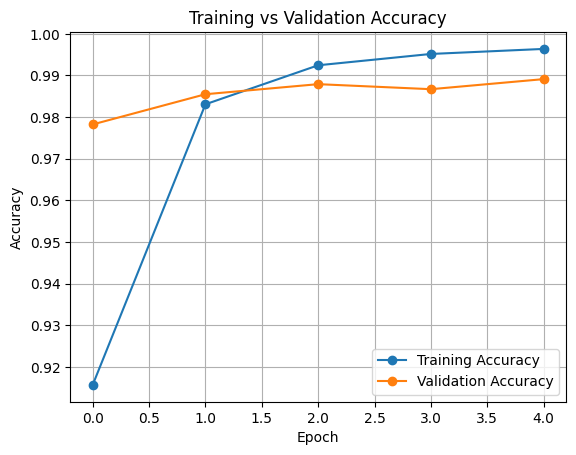

In [33]:

# Plot training accuracy
plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

# Plot validation accuracy
plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

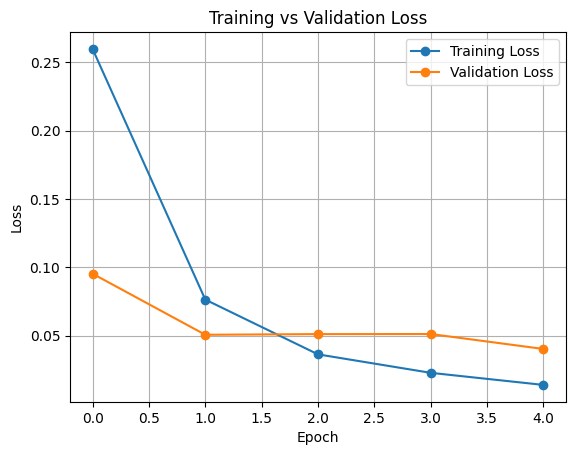

In [34]:
# Plot training loss
plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

# Plot validation loss
plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [35]:

# FIVE DATA-GROUNDED INSIGHTS


# Total number of messages
total_messages = len(df)

# Number of ham and spam messages
ham_count = (df["label"] == "ham").sum()
spam_count = (df["label"] == "spam").sum()

# Percentage of spam messages
spam_percentage = (spam_count / total_messages) * 100


# Average message length
ham_avg_length = df.loc[
    df["label"] == "ham",
    "text_length"
].mean()

spam_avg_length = df.loc[
    df["label"] == "spam",
    "text_length"
].mean()


# Average word count
ham_avg_words = df.loc[
    df["label"] == "ham",
    "word_count"
].mean()

spam_avg_words = df.loc[
    df["label"] == "spam",
    "word_count"
].mean()


# Percentage of messages containing currency symbols
ham_currency = (
    df.loc[
        df["label"] == "ham",
        "contains_currency"
    ].mean()
) * 100

spam_currency = (
    df.loc[
        df["label"] == "spam",
        "contains_currency"
    ].mean()
) * 100


# Average number of digits
ham_digits = df.loc[
    df["label"] == "ham",
    "digit_count"
].mean()

spam_digits = df.loc[
    df["label"] == "spam",
    "digit_count"
].mean()


# Print the final insights.
# Using print() ensures the actual numeric values are stored
# visibly in the notebook output.

print("FIVE DATA-GROUNDED INSIGHTS")
print("=" * 50)

print(
    f"1. Class Distribution: The cleaned dataset contains "
    f"{total_messages} messages: {ham_count} ham and {spam_count} spam. "
    f"Spam represents approximately {spam_percentage:.2f}% of the dataset."
)

print(
    f"\n2. Message Length: Ham messages contain an average of "
    f"{ham_avg_length:.1f} characters, while spam messages contain "
    f"an average of {spam_avg_length:.1f} characters."
)

print(
    f"\n3. Word Count: Ham messages contain approximately "
    f"{ham_avg_words:.1f} words on average, compared with "
    f"{spam_avg_words:.1f} words for spam messages."
)

print(
    f"\n4. Currency Symbols: Approximately {ham_currency:.2f}% "
    f"of ham messages contain a currency symbol, compared with "
    f"{spam_currency:.2f}% of spam messages."
)

print(
    f"\n5. Numeric Digits: Ham messages contain an average of "
    f"{ham_digits:.2f} numeric digits, while spam messages contain "
    f"an average of {spam_digits:.2f} digits."
)

FIVE DATA-GROUNDED INSIGHTS
1. Class Distribution: The cleaned dataset contains 5169 messages: 4516 ham and 653 spam. Spam represents approximately 12.63% of the dataset.

2. Message Length: Ham messages contain an average of 70.5 characters, while spam messages contain an average of 137.9 characters.

3. Word Count: Ham messages contain approximately 14.1 words on average, compared with 23.7 words for spam messages.

4. Currency Symbols: Approximately 0.40% of ham messages contain a currency symbol, compared with 33.23% of spam messages.

5. Numeric Digits: Ham messages contain an average of 0.29 numeric digits, while spam messages contain an average of 15.45 digits.


Forget Gate Explanation: The forget gate allows an LSTM to decide which previous information should be kept and which information should be removed from its memory. This allows an LSTM to retain useful information over longer sequences, while a plain RNN is more likely to lose long-term information because of the vanishing-gradient problem.